In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

Daten erfolgreich geladen.


=== Optimierte Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       229474 non-null  int8 
 1   HighBP                229474 non-null  int8 
 2   HighChol              229474 non-null  int8 
 3   CholCheck             229474 non-null  int8 
 4   BMI                   229474 non-null  int8 
 5   Smoker                229474 non-null  int8 
 6   Stroke                229474 non-null  int8 
 7   HeartDiseaseorAttack  229474 non-null  int8 
 8   PhysActivity          229474 non-null  int8 
 9   Fruits                229474 non-null  int8 
 10  Veggies               229474 non-null  int8 
 11  HvyAlcoholConsump     229474 non-null  int8 
 12  AnyHealthcare         229474 non-null  int8 
 13  NoDocbcCost           229474 non-null  int8 
 14  GenHlth               229474 non-nul

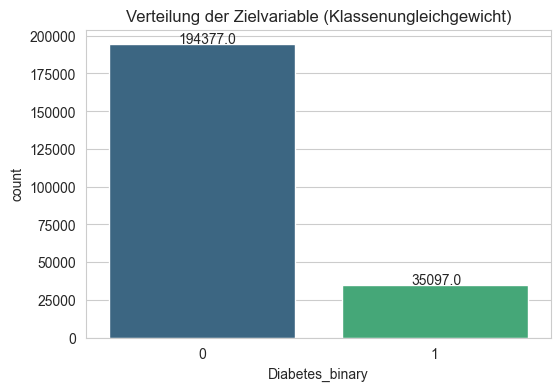


=== Klassenverteilung ===
Diabetes_binary
0    0.847055
1    0.152945
Name: proportion, dtype: float64
Hinweis: Starkes Ungleichgewicht erkannt! (Strategien wie SMOTE oder class_weights erwägen)


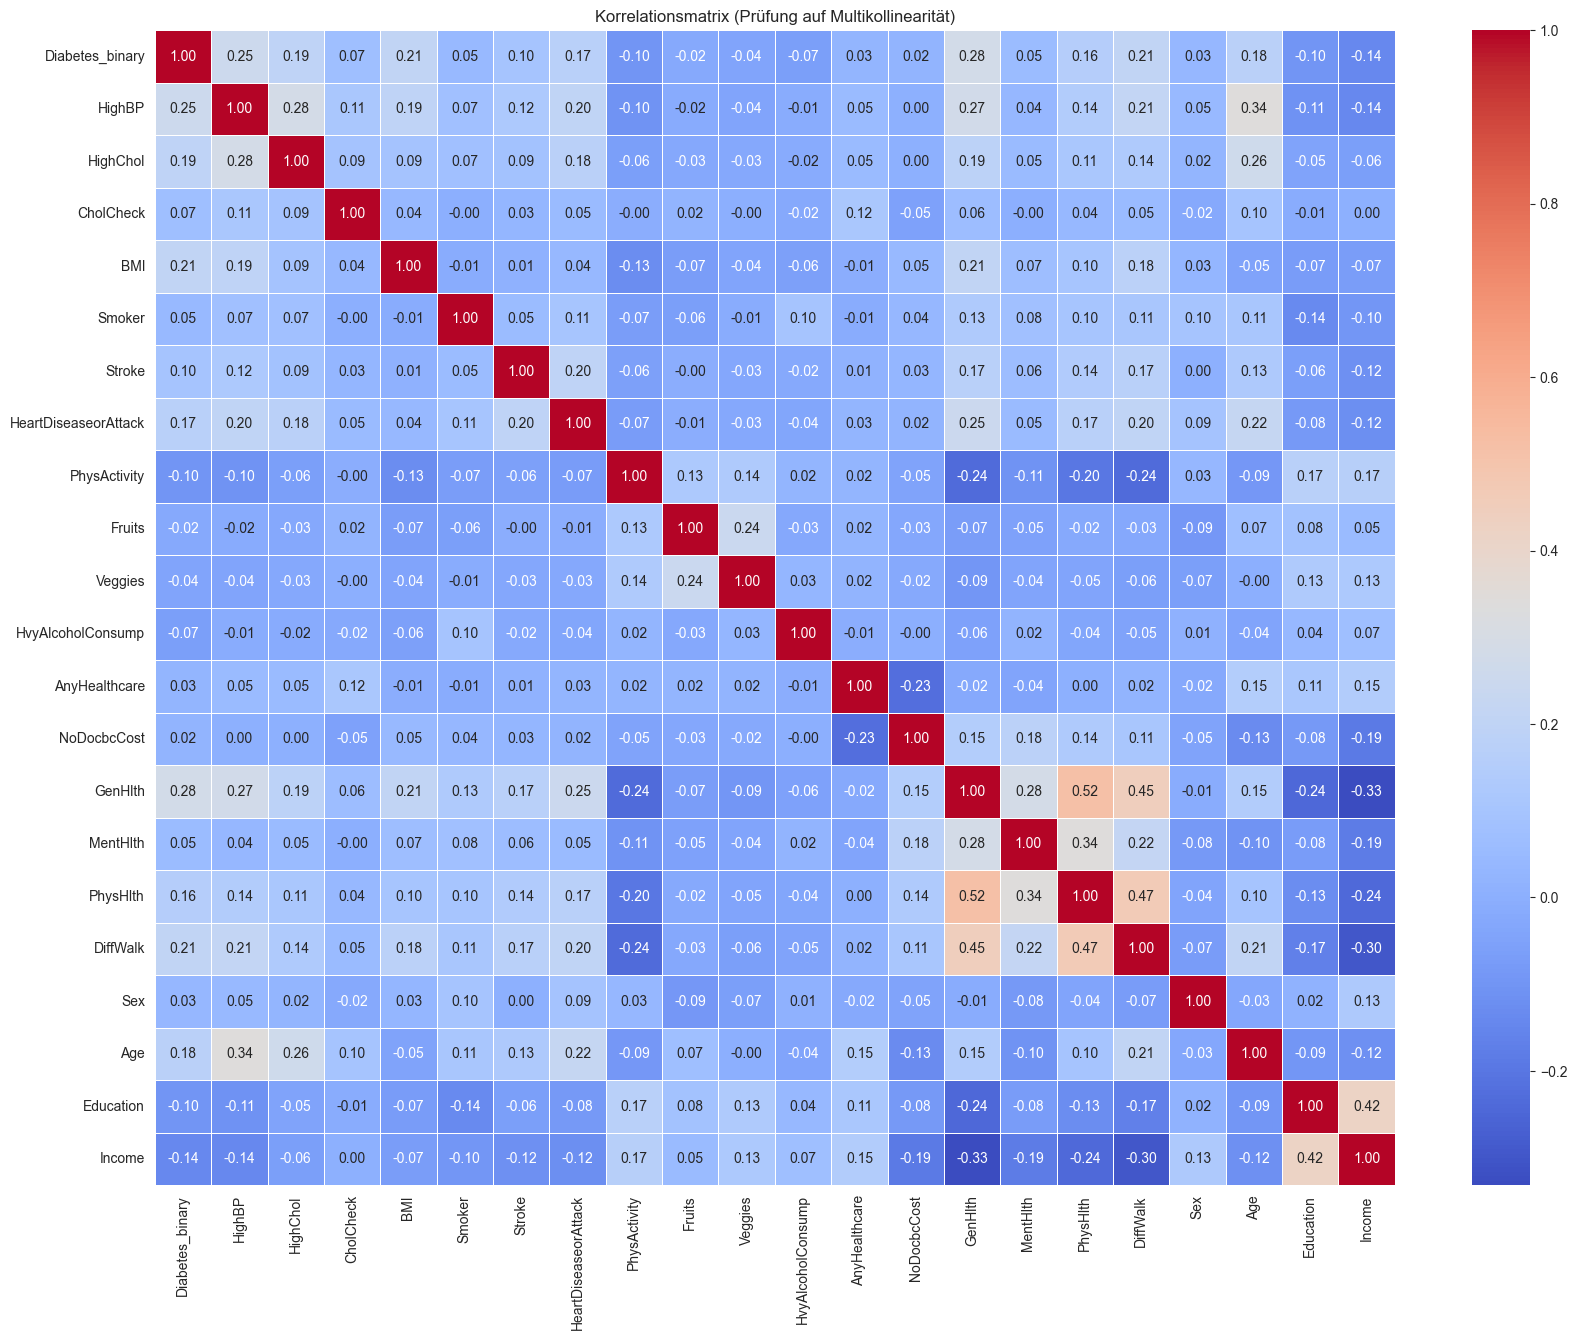


Features ausgewählt: 16


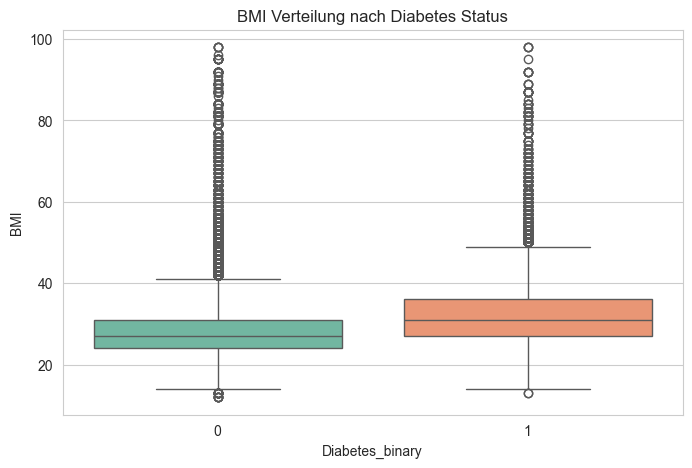

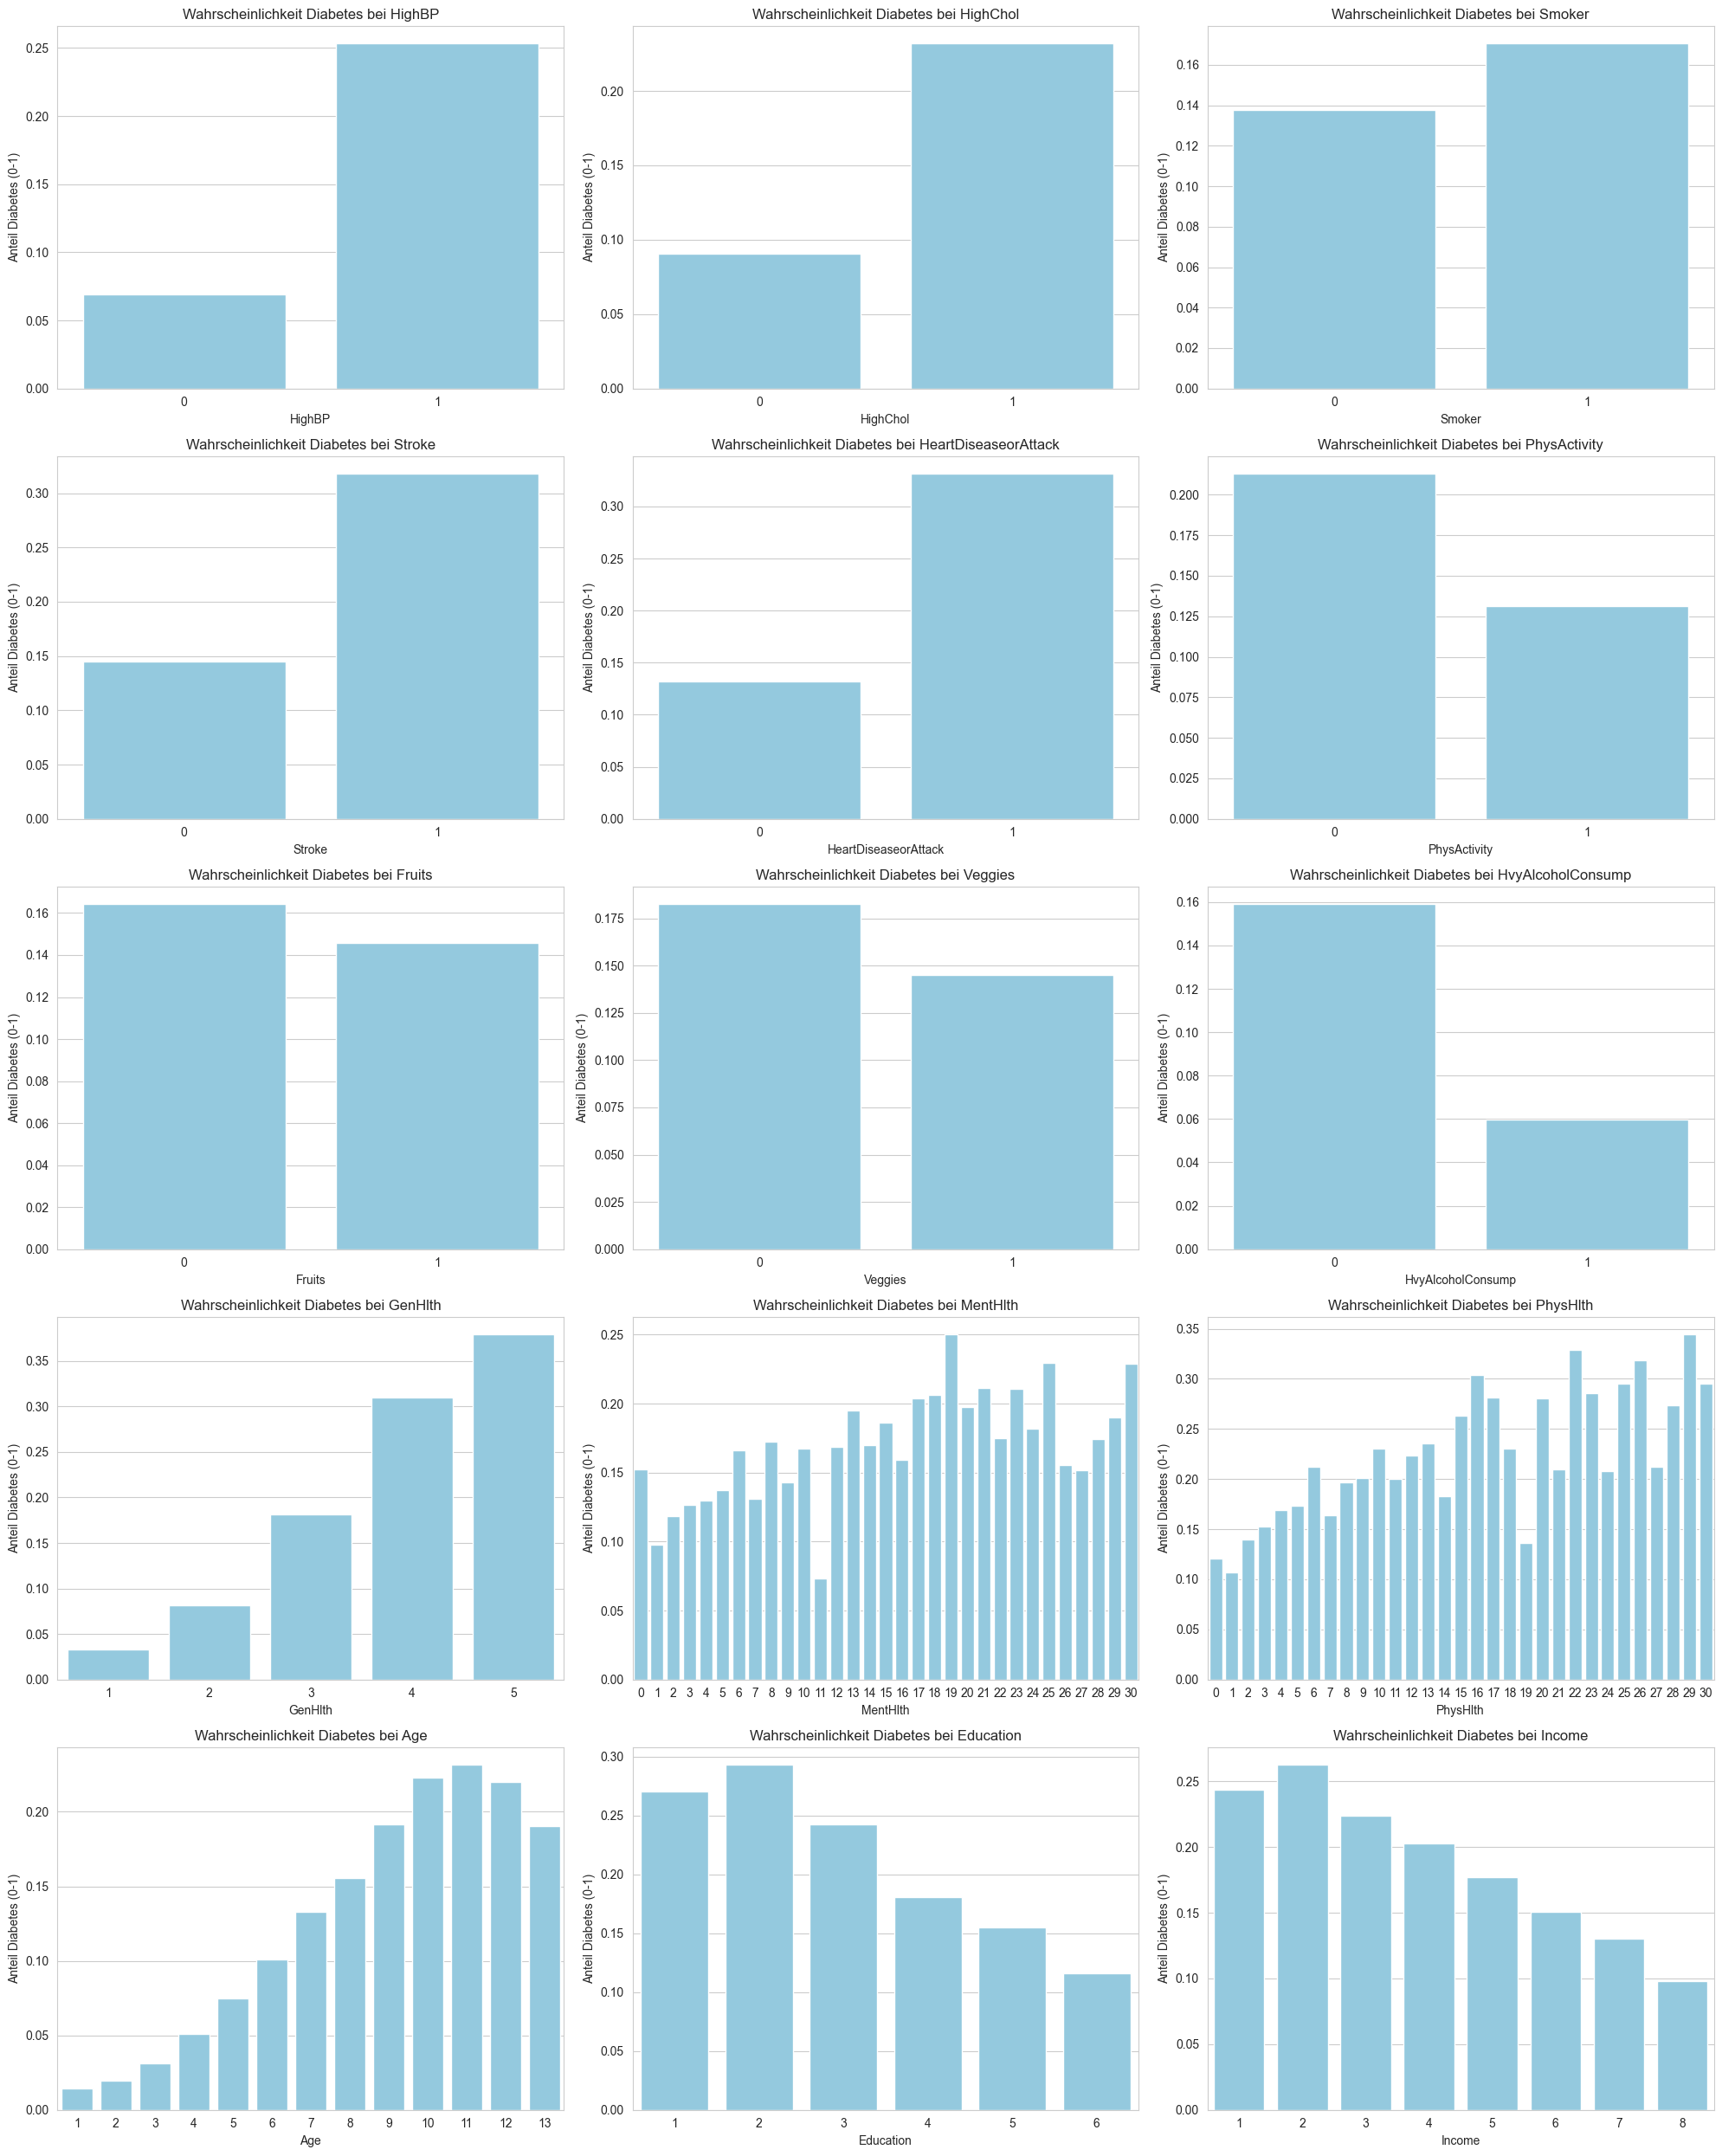


Feature-Liste gespeichert unter: ../ml/model\selected_features.json
Exploration abgeschlossen.


In [4]:
# Ziel: Daten verstehen, Features auswählen, für Modell vorbereiten

# Einstellungen
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# 1. Daten laden
try:
    df = pd.read_csv('../data/diabetes_binary_health_indicators_BRFSS2015.csv')
    print("Daten erfolgreich geladen.")
except FileNotFoundError:
    print("Fehler: Datei nicht gefunden. Bitte Pfad überprüfen.")
    exit()

# 2. Datenbereinigung & Optimierung

# Duplikate prüfen und entfernen
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\nWARNING: {duplicates} Duplikate gefunden. Diese werden entfernt.")
    df.drop_duplicates(inplace=True)

# Daten optimieren
for col in df.columns:
    if df[col].max() < 127: # Passt in int8
        df[col] = df[col].astype('int8')
    else:
        df[col] = df[col].astype('int16')

print("\n=== Optimierte Info ===")
print(df.info())

# 3. Basis Statistik
print("\n=== Missing Values ===")
print(df.isnull().sum().sum()) # Summe aller fehlenden Werte

# Zielvariable Verteilung
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Diabetes_binary', data=df, palette='viridis')
plt.title('Verteilung der Zielvariable (Klassenungleichgewicht)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+500))
plt.show()

# Prozentuale Verteilung berechnen
imbalance_ratio = df['Diabetes_binary'].value_counts(normalize=True)
print("\n=== Klassenverteilung ===")
print(imbalance_ratio)
if imbalance_ratio[1] < 0.2:
    print("Hinweis: Starkes Ungleichgewicht erkannt! (Strategien wie SMOTE oder class_weights erwägen)")

# 4 Feature Selektion

#Korrelationen
plt.figure(figsize=(20, 15))
heatmap = sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Korrelationsmatrix (Prüfung auf Multikollinearität)')
plt.show()

#Definiere Features
selected_features = [
    'HighBP',           # Bluthochdruck
    'HighChol',         # Hoher Cholesterin
    'BMI',              # Body Mass Index
    'Smoker',           # Raucher
    'Stroke',           # Schlaganfall in Vergangenheit
    'HeartDiseaseorAttack',  # Herzerkrankung
    'PhysActivity',     # Körperliche Aktivität
    'Fruits',           # Obstkonsum
    'Veggies',          # Gemüsekonsum
    'HvyAlcoholConsump', # Starker Alkoholkonsum
    'GenHlth',          # Allgemeine Gesundheit
    'MentHlth',         # Psychische Gesundheit
    'PhysHlth',         # Körperliche Gesundheit
    'Age',              # Alter
    'Education',        # Bildung
    'Income'            # Einkommen
]

print(f"\nFeatures ausgewählt: {len(selected_features)}")

# 5 Visualisierung der Features

# # Unterscheidung für bessere Plots: BMI ist stetig, der Rest eher ordinal/kategorisch
continuous_features = ['BMI']
categorical_features = [f for f in selected_features if f not in continuous_features]

# Plot für BMI (Boxplot ist besser für stetige Verteilungen)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Diabetes_binary', y='BMI', data=df, palette='Set2')
plt.title('BMI Verteilung nach Diabetes Status')
plt.show()

# Plots für Kategorische Features
fig, axes = plt.subplots(5, 3, figsize=(20, 25)) # 15 Plots
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if i < len(axes):
        # Zeige den Anteil von Diabetikern pro Kategorie
        prop_data = df.groupby(feature)['Diabetes_binary'].mean().reset_index()
        sns.barplot(x=feature, y='Diabetes_binary', data=prop_data, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Wahrscheinlichkeit Diabetes bei {feature}')
        axes[i].set_ylabel('Anteil Diabetes (0-1)')

plt.tight_layout()
plt.show()

# 6 Speichern

# Sicherstellen, dass der Ordner existiert
output_dir = '../ml/model'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'selected_features.json')

with open(output_path, 'w') as f:
    json.dump(selected_features, f)

print(f"\nFeature-Liste gespeichert unter: {output_path}")
print("Exploration abgeschlossen.")